# 第5章：Pretraining on Unlabeled Data

**目标：** 训练第4章搭建的 GPT 模型，让它真正学会生成有意义的文本，并加载 OpenAI 发布的 GPT-2 预训练权重

```
评估模型(loss) → 训练循环 → 解码策略(temperature/top-k) → 加载 GPT-2 权重 → 生成真正的文本
```

**前置回顾（第2-4章）：**
- 第2章：文本 → Token IDs → DataLoader（batch + sliding window）
- 第3章：Multi-Head Causal Attention 让每个 token 融合上下文
- 第4章：完整 GPT 模型 + Greedy Decoding 文本生成
- 现在的问题：模型权重是随机初始化的，生成的文本毫无意义 → **需要训练！**

---

## 5.1 评估模型：交叉熵损失 ⭐

在训练之前，我们先搞清楚如何**衡量模型的好坏**。

GPT 的训练目标是**下一个 token 预测（Next Token Prediction）**：
- 给定 `[t₁, t₂, ..., tₙ]`，模型需要预测 `[t₂, t₃, ..., tₙ₊₁]`
- 每个位置输出一个 `vocab_size` 维的 logits 向量
- 通过 softmax 转成概率分布，用**交叉熵损失**衡量与真实 token 的差距

**交叉熵损失（Cross-Entropy Loss）：**

$$L = -\frac{1}{N}\sum_{i=1}^{N} \log P(t_i^{\text{target}} | t_1, ..., t_{i-1})$$

- 如果模型对正确 token 给出高概率 → 损失小
- 如果模型对正确 token 给出低概率 → 损失大

**与困惑度（Perplexity）的关系：**

$$\text{Perplexity} = e^{\text{Cross-Entropy Loss}}$$

- 困惑度可以理解为「模型在每个位置平均犹豫多少个 token」
- 随机猜测时，perplexity ≈ vocab_size（50,257）
- 训练良好的模型，perplexity 通常在 10-50 之间

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import tiktoken
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = ['Arial Unicode MS']
matplotlib.rcParams['axes.unicode_minus'] = False

# ─── 第4章的所有组件（直接复用）───────────────────────────────────

# GPT-2 Small (124M) 的超参数配置
GPT_CONFIG_124M = {
    "vocab_size": 50257,      # BPE 词汇表大小
    "context_length": 1024,   # 最大序列长度（位置编码上限）
    "emb_dim": 768,           # 嵌入维度 / 隐藏层维度
    "n_heads": 12,            # 多头注意力的头数（每头 768/12=64 维）
    "n_layers": 12,           # Transformer Block 堆叠层数
    "drop_rate": 0.1,         # Dropout 概率
    "qkv_bias": False,        # Q/K/V 线性投影是否带偏置项
}


class MultiHeadAttention(nn.Module):
    """多头因果自注意力（第3章）
    将输入通过 Q/K/V 投影拆分成多个注意力头，并行计算后合并。
    使用上三角掩码实现因果性：每个 token 只能看到自己及之前的 token。
    """
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out 必须能被 num_heads 整除"
        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads  # 每个注意力头的维度

        # Q/K/V 线性投影：(d_in) → (d_out)
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)  # 多头合并后的输出投影
        self.dropout  = nn.Dropout(dropout)

        # 因果掩码：上三角矩阵，阻止 token 关注未来位置
        self.register_buffer(
            'mask',
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape

        # 线性投影得到 Q/K/V
        queries = self.W_query(x)  # (b, seq, d_out)
        keys    = self.W_key(x)
        values  = self.W_value(x)

        # 拆分成多头: (b, seq, d_out) → (b, num_heads, seq, head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        keys    = keys.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        values  = values.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)

        # 计算注意力分数: Q @ K^T → (b, num_heads, seq, seq)
        attn_scores = queries @ keys.transpose(2, 3)

        # 应用因果掩码：未来位置设为 -inf，softmax 后变为 0
        attn_scores.masked_fill_(
            self.mask[:num_tokens, :num_tokens].bool(), -torch.inf
        )

        # 缩放 + softmax 归一化 + dropout
        attn_weights = F.softmax(attn_scores / self.head_dim**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # 加权求和: (b, num_heads, seq, seq) @ (b, num_heads, seq, head_dim)
        context_vecs = attn_weights @ values

        # 合并多头: (b, num_heads, seq, head_dim) → (b, seq, d_out)
        context_vecs = context_vecs.transpose(1, 2).contiguous().view(b, num_tokens, self.d_out)
        context_vecs = self.out_proj(context_vecs)  # 输出投影
        return context_vecs


class LayerNorm(nn.Module):
    """层归一化（第4章）
    对每个样本的特征维度做归一化（均值→0, 方差→1），
    然后通过可学习的 scale 和 shift 恢复表达能力。
    """
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5                                    # 防止除零的小常数
        self.scale = nn.Parameter(torch.ones(emb_dim))     # 可学习的缩放参数 γ
        self.shift = nn.Parameter(torch.zeros(emb_dim))    # 可学习的偏移参数 β

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)  # 有偏方差（与 GPT-2 原版一致）
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift


class GELU(nn.Module):
    """GELU 激活函数（第4章）
    近似公式: 0.5 * x * (1 + tanh(√(2/π) * (x + 0.044715 * x³)))
    相比 ReLU 更平滑，负值区域有非零梯度，更适合 LLM 训练。
    """
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x, 3))
        ))


class FeedForward(nn.Module):
    """前馈网络（第4章）
    两层线性变换 + GELU 激活: emb_dim → 4*emb_dim → emb_dim
    先扩展到 4 倍维度做非线性变换，再压缩回原始维度。
    """
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),  # 扩展层
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),  # 压缩层
        )

    def forward(self, x):
        return self.layers(x)


class TransformerBlock(nn.Module):
    """Transformer Block（第4章）— GPT 的基本构建单元
    采用 Pre-LN 架构（先 Norm 再计算），每个子层都有残差连接：
      x → LN → Multi-Head Attention → Dropout → +x（残差）
      x → LN → FeedForward → Dropout → +x（残差）
    """
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"],
        )
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])  # 注意力子层前的 LayerNorm
        self.norm2 = LayerNorm(cfg["emb_dim"])  # FFN 子层前的 LayerNorm
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # 子层 1: Multi-Head Attention + 残差
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)
        x = self.drop_shortcut(x)
        x = x + shortcut       # 残差连接：防止梯度消失

        # 子层 2: FeedForward + 残差
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut       # 残差连接
        return x


class GPTModel(nn.Module):
    """完整的 GPT 模型（第4章）
    数据流: Token IDs → Embedding → N×TransformerBlock → LayerNorm → Linear → logits
    输入: (batch, seq_len) 的 token ID 张量
    输出: (batch, seq_len, vocab_size) 的 logits（未归一化概率）
    """
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])    # token 嵌入
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])  # 位置嵌入
        self.drop_emb = nn.Dropout(cfg["drop_rate"])                      # 嵌入层 dropout

        # 堆叠 n_layers 个 TransformerBlock
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )
        self.final_norm = LayerNorm(cfg["emb_dim"])  # 最后一层 LayerNorm

        # 输出头: 将隐藏状态映射到词汇表维度 → logits
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)                                    # (b, seq, emb_dim)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))  # (seq, emb_dim)
        x = tok_embeds + pos_embeds  # token 嵌入 + 位置嵌入（广播相加）
        x = self.drop_emb(x)
        x = self.trf_blocks(x)      # 经过所有 Transformer Block
        x = self.final_norm(x)
        logits = self.out_head(x)    # (b, seq, vocab_size)
        return logits


def generate_text_simple(model, idx, max_new_tokens, context_size):
    """贪心解码（Greedy Decoding）— 每步选概率最高的 token
    Args:
        model: GPT 模型
        idx: 初始 token IDs，shape (batch, seq)
        max_new_tokens: 最多生成的新 token 数
        context_size: 模型的最大上下文长度（超出则截断）
    Returns:
        扩展后的 token IDs，shape (batch, seq + max_new_tokens)
    """
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]       # 截断到上下文窗口
        with torch.no_grad():
            logits = model(idx_cond)            # 前向推理
        logits = logits[:, -1, :]               # 只取最后一个位置的预测
        probas = torch.softmax(logits, dim=-1)
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)  # 贪心: 取 argmax
        idx = torch.cat((idx, idx_next), dim=1)  # 追加新 token
    return idx


# ─── 初始化 ──────────────────────────────────────────────────────
tokenizer = tiktoken.get_encoding("gpt2")
print("第4章组件加载完毕 ✓")
print(f"GPT-2 124M 配置: {GPT_CONFIG_124M}")

第4章组件加载完毕 ✓
GPT-2 124M 配置: {'vocab_size': 50257, 'context_length': 1024, 'emb_dim': 768, 'n_heads': 12, 'n_layers': 12, 'drop_rate': 0.1, 'qkv_bias': False}


In [17]:
# 用两个简单句子直观理解交叉熵损失
txt1 = "Every effort moves you"
txt2 = "Every day holds a"

batch = torch.stack([
    torch.tensor(tokenizer.encode(txt1)),
    torch.tensor(tokenizer.encode(txt2)),
], dim=0)
print(f"输入 batch shape: {batch.shape}")
print(f"  txt1 tokens: {tokenizer.encode(txt1)}")
print(f"  txt2 tokens: {tokenizer.encode(txt2)}")

输入 batch shape: torch.Size([2, 4])
  txt1 tokens: [6109, 3626, 6100, 345]
  txt2 tokens: [6109, 1110, 6622, 257]


In [18]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval()

logits = model(batch)
print(f"logits shape: {logits.shape}")
print(f"→ (batch=2, seq_len=4, vocab_size=50257)")

logits shape: torch.Size([2, 4, 50257])
→ (batch=2, seq_len=4, vocab_size=50257)


### 从 logits 到损失

**训练目标**是让模型预测序列中的下一个 token：
```
输入:  [Every,  effort, moves, you]
目标:  [effort, moves,  you,   <end>]
```

对于我们的两句话：
- 输入 `[Every, effort, moves]` → 目标 `[effort, moves, you]`
- 输入 `[Every, day, holds]` → 目标 `[day, holds, a]`

In [19]:
# 构造输入和目标
inputs = batch[:, :-1]   # 去掉最后一个 token
targets = batch[:, 1:]   # 去掉第一个 token（向右移一位）

print(f"inputs:  {inputs.shape}")
print(f"targets: {targets.shape}")
print(f"\n输入tokens:")
for i, row in enumerate(inputs):
    print(f"  句子{i+1}: {[tokenizer.decode([t.item()]) for t in row]}")
print(f"目标tokens:")
for i, row in enumerate(targets):
    print(f"  句子{i+1}: {[tokenizer.decode([t.item()]) for t in row]}")

inputs:  torch.Size([2, 3])
targets: torch.Size([2, 3])

输入tokens:
  句子1: ['Every', ' effort', ' moves']
  句子2: ['Every', ' day', ' holds']
目标tokens:
  句子1: [' effort', ' moves', ' you']
  句子2: [' day', ' holds', ' a']


In [20]:
# 手动计算交叉熵损失
with torch.no_grad():
    logits = model(inputs)

print(f"logits shape: {logits.shape}")

# 展平: (batch*seq_len, vocab_size) 和 (batch*seq_len,)
logits_flat = logits.flatten(0, 1)     # (6, 50257)
targets_flat = targets.flatten()        # (6,)
print(f"展平后 logits: {logits_flat.shape}")
print(f"展平后 targets: {targets_flat.shape}")

loss = F.cross_entropy(logits_flat, targets_flat)
print(f"\n交叉熵损失: {loss.item():.4f}")

perplexity = torch.exp(loss)
print(f"困惑度 (Perplexity): {perplexity.item():.2f}")
print(f"\n→ 随机猜测时 perplexity ≈ vocab_size = {GPT_CONFIG_124M['vocab_size']}")
print(f"→ 当前 perplexity = {perplexity.item():.0f}，说明模型完全没学到东西（符合预期）")

logits shape: torch.Size([2, 3, 50257])
展平后 logits: torch.Size([6, 50257])
展平后 targets: torch.Size([6])

交叉熵损失: 11.1666
困惑度 (Perplexity): 70725.68

→ 随机猜测时 perplexity ≈ vocab_size = 50257
→ 当前 perplexity = 70726，说明模型完全没学到东西（符合预期）


Perplexity > 50257 并非无意义，它说明模型在积极地往错误方向预测

> 💡 **关键洞察：** 未训练模型的 perplexity ≈ vocab_size，因为它对每个 token 几乎等概率猜测。
> 训练的目标就是**降低这个损失**，让模型对正确的下一个 token 给出更高的概率。

### ✏️ 练习
1. 手动验证：`F.cross_entropy` 的结果等价于先 softmax 再取 `-log`。用 `logits_flat[0]` 和 `targets_flat[0]` 手动算一遍。
2. 如果模型对正确 token 的概率是 0.5，交叉熵损失是多少？概率是 0.01 呢？

In [21]:
# 在这里做实验
import torch
import torch.nn.functional as F

# 假设某位置的 logits 和正确答案
logits = torch.tensor([2.0, 1.0, 0.1])  # 3个类别
target = 0  # 正确答案是第0类

# 手动算
probs = torch.softmax(logits, dim=0)       # [0.659, 0.242, 0.099]
loss_manual = -torch.log(probs[target])     # -log(0.659) = 0.417

# PyTorch 一步到位（结果一样）
loss_pytorch = F.cross_entropy(logits.unsqueeze(0), torch.tensor([target]))

print(f"手动: {loss_manual:.4f}")
print(f"PyTorch: {loss_pytorch:.4f}")
# 两者输出相同: 0.4170

# probs = 0.5
probs1 = 0.5
probs2 = 0.01
print(f"probs1: {probs1:.4f}")
print(f"probs2: {probs2:.4f}")
loss_probs1 = -torch.log(torch.tensor(probs1))
loss_probs2 = -torch.log(torch.tensor(probs2))
print(f"loss_probs1: {loss_probs1:.4f}")
print(f"loss_probs2: {loss_probs2:.4f}")
# 结果:
# loss_probs1: 0.6931
# loss_probs2: 4.6052

手动: 0.4170
PyTorch: 0.4170
probs1: 0.5000
probs2: 0.0100
loss_probs1: 0.6931
loss_probs2: 4.6052


---
## 5.2 准备训练数据 ⭐

我们将使用第2章的方法，将文本加载为训练用的 DataLoader。

为了演示训练过程，我们使用 Edith Wharton 的短篇小说 *The Verdict* 作为训练数据（约 20KB）。

**为什么用这么小的数据集？**
- 真正的 GPT 预训练需要数十 GB 数据和数千 GPU 小时
- 这里用小数据集是为了**在几分钟内走通整个训练流程**
- 理解了训练流程后，第 5.5 节我们会加载 OpenAI 发布的 GPT-2 预训练权重

In [22]:
import os
import urllib.request

file_path = "the-verdict.txt"
url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch02/01_main-chapter-code/the-verdict.txt"

# 优先使用本地 data 目录中的文件
local_data_path = os.path.join("..", "data", "the-verdict.txt")
if os.path.exists(local_data_path):
    file_path = local_data_path
    print(f"使用本地文件: {file_path}")
elif not os.path.exists(file_path):
    urllib.request.urlretrieve(url, file_path)
    print(f"已下载: {file_path}")

with open(file_path, "r", encoding="utf-8") as f:
    raw_text = f.read()

total_characters = len(raw_text)
total_tokens = len(tokenizer.encode(raw_text))

print(f"\n文本长度: {total_characters:,} 字符")
print(f"Token 数量: {total_tokens:,}")
print(f"前 200 字符: {raw_text[:200]}...")

使用本地文件: ../data/the-verdict.txt

文本长度: 20,479 字符
Token 数量: 5,145
前 200 字符: I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no great surprise to me to hear that, in the height of his glory, he had dropped his painting, married a...


In [23]:
from torch.utils.data import Dataset, DataLoader


class GPTDatasetV1(Dataset):
    """第2章实现的 GPT 数据集：用滑动窗口将文本切分为 (input, target) 对"""
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        token_ids = tokenizer.encode(txt)
        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i:i + max_length]
            target_chunk = token_ids[i + 1:i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]


def create_dataloader_v1(txt, batch_size=4, max_length=256,
                         stride=128, shuffle=True, drop_last=True,
                         num_workers=0):
    tokenizer = tiktoken.get_encoding("gpt2")
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers,
    )
    return dataloader

In [24]:
# 划分训练集和验证集（90% / 10%）
train_ratio = 0.90
split_idx = int(train_ratio * len(raw_text))
train_data = raw_text[:split_idx]
val_data = raw_text[split_idx:]

print(f"训练集: {len(train_data):,} 字符")
print(f"验证集: {len(val_data):,} 字符")

训练集: 18,431 字符
验证集: 2,048 字符


In [25]:
# 创建 DataLoader
# 使用较小的 context_length 以加快训练（真实 GPT-2 用 1024）
torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=256,
    stride=128,
    shuffle=True,
    drop_last=True,
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=256,
    stride=128,
    shuffle=False,
    drop_last=False,
)

print(f"训练 batches: {len(train_loader)}")
print(f"验证 batches: {len(val_loader)}")

# 检查一个 batch
for x, y in train_loader:
    print(f"\n第一个 batch:")
    print(f"  x shape: {x.shape}")
    print(f"  y shape: {y.shape}")
    break

# token 总量
train_tokens = 0
for x, y in train_loader:
    train_tokens += x.numel()
val_tokens = 0
for x, y in val_loader:
    val_tokens += x.numel()
print(f"\n训练 tokens: {train_tokens:,}")
print(f"验证 tokens: {val_tokens:,}")

训练 batches: 17
验证 batches: 2

第一个 batch:
  x shape: torch.Size([2, 256])
  y shape: torch.Size([2, 256])

训练 tokens: 8,704
验证 tokens: 768


> 💡 **关键参数说明：**
> - `max_length=256`：每个样本的序列长度（比 GPT-2 的 1024 小，加速训练）
> - `stride=128`：滑动窗口步长（小于 max_length，产生重叠样本，增大训练数据量）
> - `drop_last=True`：丢弃最后不完整的 batch，保证所有 batch 大小一致

### ✏️ 练习
1. 改变 `stride` 的值（设为 256 即无重叠），观察训练 batches 数量的变化。
2. 如果 `max_length=1024`（GPT-2 原始设置），训练 batches 会变成多少？

In [26]:
# 在这里做实验
train_loader2 = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=1024,
    stride=128,
    shuffle=True,
    drop_last=True,
)

train_tokens2 = 0
for x, y in train_loader2:
    train_tokens2 += x.numel()
    
print(f"\n训练 tokens: {train_tokens2:,}")



训练 tokens: 28,672


---
## 5.3 训练循环 ⭐⭐⭐

现在进入本章最核心的部分——**训练循环**。

GPT 的训练流程和标准深度学习训练完全一样：

```
for epoch in epochs:
    for batch in train_loader:
        1. 前向传播：logits = model(inputs)
        2. 计算损失：loss = cross_entropy(logits, targets)
        3. 反向传播：loss.backward()
        4. 更新参数：optimizer.step()
```

**训练策略：**
- 优化器：AdamW（Adam + weight decay，LLM 标准优化器）
- 学习率：`5e-4`（GPT-2 原论文使用的学习率量级）
- Weight Decay：`0.1`（防止过拟合的正则化）
- 训练过程中定期评估验证集损失，确认模型没有过拟合

In [27]:
def calc_loss_batch(input_batch, target_batch, model, device):
    """计算单个 batch 的交叉熵损失"""
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    logits = model(input_batch)
    loss = F.cross_entropy(
        logits.flatten(0, 1),
        target_batch.flatten()
    )
    return loss


def calc_loss_loader(data_loader, model, device, num_batches=None):
    """计算整个 DataLoader 的平均损失"""
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))

    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i >= num_batches:
            break
        loss = calc_loss_batch(input_batch, target_batch, model, device)
        total_loss += loss.item()

    return total_loss / num_batches

In [28]:
# 评估未训练模型的损失
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"使用设备: {device}")

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
model.eval()

with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

print(f"\n训练集损失: {train_loss:.4f}")
print(f"验证集损失: {val_loss:.4f}")
print(f"\n→ 未训练模型的损失 ≈ ln(50257) ≈ {torch.log(torch.tensor(50257.)).item():.2f}")
print(f"→ 这说明模型在随机猜测")

使用设备: mps

训练集损失: 10.9873
验证集损失: 11.0008

→ 未训练模型的损失 ≈ ln(50257) ≈ 10.82
→ 这说明模型在随机猜测


In [29]:
def train_model_simple(model, train_loader, val_loader, optimizer, device,
                       num_epochs, eval_freq, eval_iter, start_context,
                       tokenizer):
    """简单的训练循环"""
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    for epoch in range(num_epochs):
        model.train()

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()
            optimizer.step()

            tokens_seen += input_batch.numel()
            global_step += 1

            # 定期评估
            if global_step % eval_freq == 0:
                model.eval()
                with torch.no_grad():
                    train_loss = calc_loss_loader(
                        train_loader, model, device, num_batches=eval_iter
                    )
                    val_loss = calc_loss_loader(
                        val_loader, model, device, num_batches=eval_iter
                    )
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, "
                      f"Val loss {val_loss:.3f}")
                model.train()

        # 每个 epoch 结束后生成示例文本
        generate_and_print_sample(
            model, tokenizer, device, start_context
        )

    return train_losses, val_losses, track_tokens_seen


def generate_and_print_sample(model, tokenizer, device, start_context):
    """用当前模型生成示例文本"""
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = tokenizer.encode(start_context)
    encoded_tensor = torch.tensor(encoded).unsqueeze(0).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded_tensor,
            max_new_tokens=50, context_size=context_size,
        )
    decoded_text = tokenizer.decode(token_ids.squeeze(0).tolist())
    print(f"  → 生成: {decoded_text}")
    model.train()

In [30]:
# 🚀 开始训练！
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.0004,
    weight_decay=0.1,
)

num_epochs = 10

print(f"模型参数量: {sum(p.numel() for p in model.parameters()):,}")
print(f"训练 epochs: {num_epochs}")
print(f"设备: {device}")
print("=" * 60)

train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs,
    eval_freq=5,
    eval_iter=5,
    start_context="Every effort moves you",
    tokenizer=tokenizer,
)

模型参数量: 163,009,536
训练 epochs: 10
设备: mps
Ep 1 (Step 000000): Train loss 10.097, Val loss 10.063
Ep 1 (Step 000005): Train loss 8.146, Val loss 8.420
Ep 1 (Step 000010): Train loss 6.682, Val loss 7.111
Ep 1 (Step 000015): Train loss 6.269, Val loss 6.687
  → 生成: Every effort moves you, a, a, a, a, and, a, and, a.

































Ep 2 (Step 000020): Train loss 5.830, Val loss 6.541
Ep 2 (Step 000025): Train loss 5.791, Val loss 6.567
Ep 2 (Step 000030): Train loss 5.590, Val loss 6.461
  → 生成: Every effort moves you.

















































Ep 3 (Step 000035): Train loss 5.393, Val loss 6.351
Ep 3 (Step 000040): Train loss 5.349, Val loss 6.489
Ep 3 (Step 000045): Train loss 5.246, Val loss 6.430
Ep 3 (Step 000050): Train loss 4.954, Val loss 6.244
  → 生成: Every effort moves you a a
















































Ep 4 (Step 000055): Train loss 4.440, Val loss 6.210
Ep 4 (Step 000060): Train loss 4.084, Val loss 6.136
Ep 4 (Step 

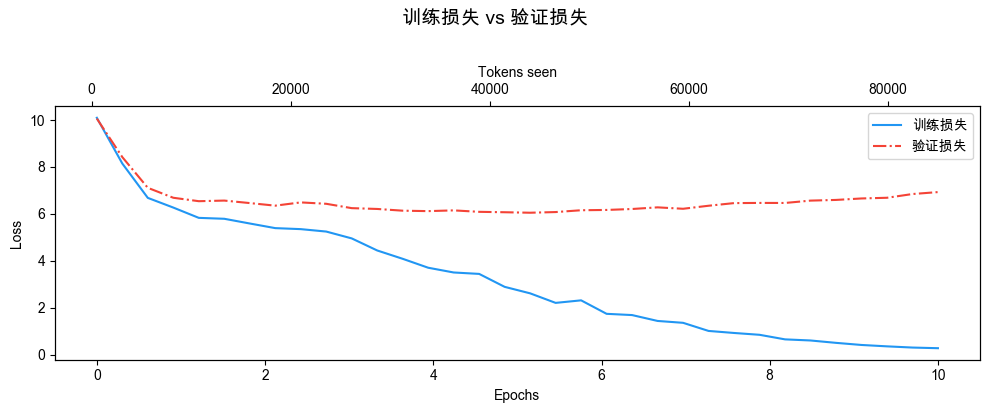

In [31]:
# 可视化训练过程
def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(10, 4))

    ax1.plot(epochs_seen, train_losses, label="训练损失", color="#2196F3")
    ax1.plot(epochs_seen, val_losses, label="验证损失",
             linestyle="-.", color="#F44336")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")

    ax2 = ax1.twiny()
    ax2.plot(tokens_seen, train_losses, alpha=0)
    ax2.set_xlabel("Tokens seen")

    fig.suptitle("训练损失 vs 验证损失", y=1.02, fontsize=14)
    fig.tight_layout()
    plt.show()


epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

> 💡 **关键观察：**
> - **训练损失持续下降** → 模型在学习训练数据中的模式
> - **验证损失先降后升（可能）** → 过拟合的信号！
> - 这是因为我们用了非常小的数据集（~5K tokens）来训练一个 1.24 亿参数的模型
> - 在真实场景中，GPT-2 使用了 ~9B tokens 训练，不容易过拟合
>
> **过拟合不是我们的重点**——本章的目标是走通训练流程，然后在 5.5 节加载预训练权重。

### ✏️ 练习
1. 修改 `num_epochs=20`，观察验证损失的变化趋势。什么时候开始明显过拟合？
2. 改变学习率（试试 `1e-3` 和 `1e-5`），观察对训练的影响。
3. （进阶）在训练循环中加入 **梯度裁剪**（`torch.nn.utils.clip_grad_norm_`），这是 LLM 训练中常用的技巧。

In [32]:
# 在这里做实验

---
## 5.4 解码策略：Temperature 和 Top-k 采样 ⭐⭐

第4章的 `generate_text_simple` 使用 **Greedy Decoding**（每次选概率最高的 token）。

这种方式的问题：
- 生成结果**确定性**的——同一个输入总是得到相同的输出
- 容易产生**重复**（模型陷入循环）
- 文本不够多样和有趣

**解决方案：引入随机性！**

### Temperature Scaling

在 softmax 之前，将 logits 除以一个 **temperature** 参数 $T$：

$$P(t_i) = \frac{e^{z_i / T}}{\sum_j e^{z_j / T}}$$

| Temperature | 效果 |
|:-----------:|------|
| $T = 1$ | 标准 softmax，正常概率分布 |
| $T < 1$ | 分布更尖锐，高概率 token 更突出 → 更保守 |
| $T > 1$ | 分布更平缓，低概率 token 也有机会 → 更有创意 |
| $T → 0$ | 退化为 greedy（只选最大的） |
| $T → ∞$ | 均匀分布（完全随机） |

### Top-k 采样

只保留概率最高的 $k$ 个 token，其余的概率设为 0 后重新归一化。

```
原始概率:  [0.3, 0.25, 0.15, 0.1, 0.08, 0.07, 0.05]
Top-3后:   [0.43, 0.36, 0.21, 0,   0,    0,    0   ]  ← 只保留前3个
```

**组合使用：** 实际中通常 Temperature + Top-k 一起使用，效果最好。

In [33]:
# 直观理解 Temperature 的效果
vocab = {0: "every", 1: "effort", 2: "moves", 3: "you", 4: "forward"}
inverse_vocab = {v: k for k, v in vocab.items()}

# 模拟一组 logits
next_token_logits = torch.tensor([4.51, 0.89, -1.90, 6.75, 1.63])

print("不同 Temperature 下的概率分布:")
print(f"{'Token':<10} {'logits':<8}", end="")

temperatures = [0.1, 0.5, 1.0, 2.0, 5.0]
for t in temperatures:
    print(f"{'T='+str(t):<8}", end="")
print()

for i in range(len(vocab)):
    print(f"{vocab[i]:<10} {next_token_logits[i].item():<8.2f}", end="")
    for t in temperatures:
        probas = torch.softmax(next_token_logits / t, dim=0)
        print(f"{probas[i].item():<8.3f}", end="")
    print()

不同 Temperature 下的概率分布:
Token      logits  T=0.1   T=0.5   T=1.0   T=2.0   T=5.0   
every      4.51    0.000   0.011   0.095   0.222   0.257   
effort     0.89    0.000   0.000   0.003   0.036   0.125   
moves      -1.90   0.000   0.000   0.000   0.009   0.071   
you        6.75    1.000   0.989   0.896   0.680   0.402   
forward    1.63    0.000   0.000   0.005   0.053   0.145   


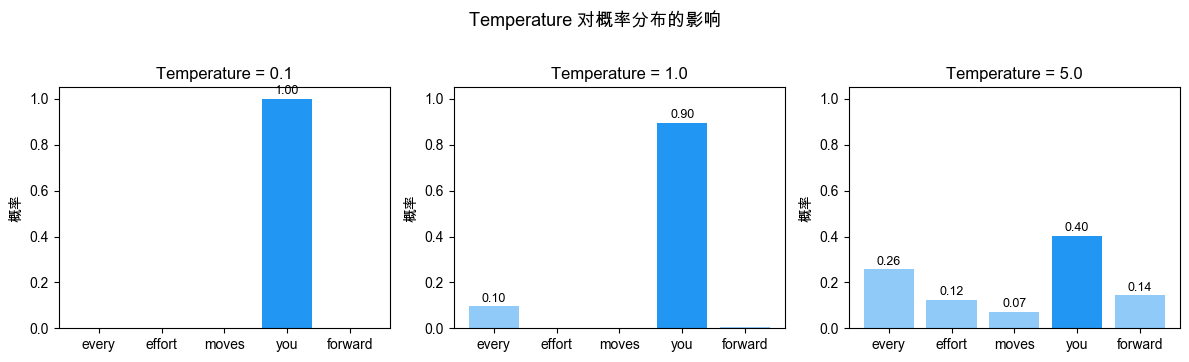

→ T=0.1: 几乎只选 'you'（最确定）
→ T=1.0: 正常分布，'you' 最高但其他也有概率
→ T=5.0: 接近均匀分布（最随机）


In [34]:
# 可视化 Temperature 效果
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
temperatures_vis = [0.1, 1.0, 5.0]

for ax, t in zip(axes, temperatures_vis):
    probas = torch.softmax(next_token_logits / t, dim=0)
    bars = ax.bar(
        [vocab[i] for i in range(len(vocab))],
        probas.numpy(),
        color=["#2196F3" if i == probas.argmax() else "#90CAF9" for i in range(len(vocab))]
    )
    ax.set_title(f"Temperature = {t}")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("概率")
    for bar, p in zip(bars, probas):
        if p > 0.01:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f"{p:.2f}", ha="center", fontsize=9)

plt.suptitle("Temperature 对概率分布的影响", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

print("→ T=0.1: 几乎只选 'you'（最确定）")
print("→ T=1.0: 正常分布，'you' 最高但其他也有概率")
print("→ T=5.0: 接近均匀分布（最随机）")

In [35]:
# Top-k 采样的实现
def top_k_logits(logits, k):
    """只保留 top-k 个 logits，其余设为 -inf"""
    top_k_values, _ = torch.topk(logits, k)
    min_val = top_k_values[:, -1]  # 第 k 大的值
    logits = torch.where(
        logits < min_val,
        torch.tensor(float("-inf")),
        logits
    )
    return logits


# 演示 Top-k
logits_example = torch.tensor([[4.51, 0.89, -1.90, 6.75, 1.63]])

print("原始 logits:", logits_example)
print()

for k in [5, 3, 1]:
    filtered = top_k_logits(logits_example, k)
    probas = torch.softmax(filtered, dim=-1)
    print(f"Top-{k}: logits={filtered.tolist()[0]}")
    print(f"        probas={[f'{p:.3f}' for p in probas.tolist()[0]]}")
    print()

原始 logits: tensor([[ 4.5100,  0.8900, -1.9000,  6.7500,  1.6300]])

Top-5: logits=[4.510000228881836, 0.8899999856948853, -1.899999976158142, 6.75, 1.6299999952316284]
        probas=['0.095', '0.003', '0.000', '0.896', '0.005']

Top-3: logits=[4.510000228881836, -inf, -inf, 6.75, 1.6299999952316284]
        probas=['0.096', '0.000', '0.000', '0.899', '0.005']

Top-1: logits=[-inf, -inf, -inf, 6.75, -inf]
        probas=['0.000', '0.000', '0.000', '1.000', '0.000']



In [36]:
def generate(model, idx, max_new_tokens, context_size,
             temperature=1.0, top_k=None, eos_id=None):
    """带 temperature 和 top-k 的文本生成"""
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]

        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]  # 只取最后一个位置

        # Top-k 过滤
        if top_k is not None:
            logits = top_k_logits(logits, top_k)

        # Temperature scaling
        if temperature > 0:
            logits = logits / temperature
            probs = torch.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)

        # 遇到 EOS 则停止
        if eos_id is not None and idx_next.item() == eos_id:
            break

        idx = torch.cat((idx, idx_next), dim=1)

    return idx

In [37]:
# 用训练后的模型对比不同解码策略
model.eval()

start_context = "Every effort moves you"
encoded = torch.tensor(tokenizer.encode(start_context)).unsqueeze(0).to(device)

print("="*70)
print(f"输入: '{start_context}'")
print("="*70)

# Greedy
torch.manual_seed(123)
out = generate(model, encoded, max_new_tokens=25,
               context_size=GPT_CONFIG_124M["context_length"],
               temperature=0)
print(f"\n🔹 Greedy (T=0):")
print(f"   {tokenizer.decode(out.squeeze().tolist())}")

# Temperature = 0.5
torch.manual_seed(123)
out = generate(model, encoded, max_new_tokens=25,
               context_size=GPT_CONFIG_124M["context_length"],
               temperature=0.5)
print(f"\n🔹 T=0.5 (保守):")
print(f"   {tokenizer.decode(out.squeeze().tolist())}")

# Temperature = 1.0
torch.manual_seed(123)
out = generate(model, encoded, max_new_tokens=25,
               context_size=GPT_CONFIG_124M["context_length"],
               temperature=1.0)
print(f"\n🔹 T=1.0 (标准):")
print(f"   {tokenizer.decode(out.squeeze().tolist())}")

# Temperature = 1.0 + Top-k = 10
torch.manual_seed(123)
out = generate(model, encoded, max_new_tokens=25,
               context_size=GPT_CONFIG_124M["context_length"],
               temperature=1.0, top_k=10)
print(f"\n🔹 T=1.0 + Top-10:")
print(f"   {tokenizer.decode(out.squeeze().tolist())}")

输入: 'Every effort moves you'

🔹 Greedy (T=0):
   Every effort moves you?"




"I wish you'd tell me how it happened," I said.






🔹 T=0.5 (保守):
   Every effort moves you?"

"Yes--quite insensible to the irony. She wanted him vindicated--and by me!"



🔹 T=1.0 (标准):
   Every effort moves youEED Monte Carlo go a brush."


" bean the tips in a flash that he never thought of theByiere

🔹 T=1.0 + Top-10:
   Every effort moves you know," was not that my hostess was "interesting": on that her husband was extracting from this circumstance a delicate but substantial


> 💡 **关键洞察：**
> - **Greedy (T=0)**：确定性输出，可能重复
> - **低 Temperature (T=0.5)**：偏保守，选择高概率词
> - **标准 Temperature (T=1.0)**：正常随机采样
> - **Temperature + Top-k**：既有随机性，又不会选太离谱的词
>
> **实际应用中的常见设置：**
> - ChatGPT 默认：T ≈ 0.7, top_p=0.95（nucleus sampling）
> - 代码生成：T ≈ 0.2（需要更确定性的输出）
> - 创意写作：T ≈ 1.0-1.5（需要更多多样性）

### 🤔 思考：Top-k vs Top-p（Nucleus Sampling）

| 方法 | 做法 | 优点 | 缺点 |
|------|------|------|------|
| Top-k | 保留前 k 个 token | 简单 | k 固定，有时保留太多或太少 |
| Top-p | 保留累积概率达到 p 的最小 token 集合 | 自适应 token 数量 | 计算稍复杂 |

**例子：**
- 如果第1个 token 概率 = 0.9，Top-p=0.95 时只需保留 1-2 个 token
- 如果概率很分散，Top-p=0.95 可能需要保留 100+ 个 token
- Top-k 不管概率分布如何，都固定保留 k 个

### ✏️ 练习
1. 固定 seed，让 temperature 从 0.1 到 2.0 逐步变化，生成 10 段文本，观察多样性的变化。
2. 实现 **Top-p (nucleus) 采样**：保留累积概率达到 p 的最小 token 集合。
3. 组合使用 Temperature=0.7 + Top-k=50，这是一个常见的工程实践参数，试试效果。

In [38]:
# 在这里做实验

---
## 5.5 加载 OpenAI GPT-2 预训练权重 ⭐⭐⭐

到目前为止，我们在一个小数据集上训练了 GPT 模型。虽然模型学到了一些模式，但生成质量远不够好。

**好消息是：** OpenAI 公开了 GPT-2 的预训练权重！我们可以直接加载这些权重到我们的模型中。

**加载流程：**
1. 从 Hugging Face 下载 GPT-2 权重（通过 `transformers` 库）
2. 将 Hugging Face 的参数名映射到我们的模型参数名
3. 逐一复制权重
4. 验证生成效果

> ⚠️ **注意：** 这里需要安装 `transformers` 库（仅用于下载权重，不用于推理）。
> ```bash
> pip install transformers
> ```

In [39]:
# 如果还没有安装 transformers，取消下面这行的注释
# !pip install transformers

In [40]:
import numpy as np

# GPT-2 各版本配置
model_configs = {
    "gpt2":         {"emb_dim": 768,  "n_layers": 12, "n_heads": 12},  # 124M
    "gpt2-medium":  {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},  # 355M
    "gpt2-large":   {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},  # 774M
    "gpt2-xl":      {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},  # 1558M
}

CHOOSE_MODEL = "gpt2"  # 选择 124M 版本

BASE_CONFIG = {
    "vocab_size": 50257,
    "context_length": 1024,
    "drop_rate": 0.0,    # 推理时关闭 dropout
    "qkv_bias": True,    # OpenAI 原版使用了 bias
}
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

print(f"选择模型: {CHOOSE_MODEL}")
print(f"配置: {BASE_CONFIG}")

选择模型: gpt2
配置: {'vocab_size': 50257, 'context_length': 1024, 'drop_rate': 0.0, 'qkv_bias': True, 'emb_dim': 768, 'n_layers': 12, 'n_heads': 12}


In [41]:
from transformers import GPT2Model as HF_GPT2Model

def download_and_load_gpt2(model_size, models_dir):
    """从 Hugging Face 下载 GPT-2 权重"""
    model_hf = HF_GPT2Model.from_pretrained(model_size, cache_dir=models_dir)
    model_hf.eval()
    params = {}
    for name, param in model_hf.named_parameters():
        params[name] = param.detach().numpy()
    # 也包含 buffers (如 attn.bias mask)
    for name, buf in model_hf.named_buffers():
        params[name] = buf.detach().numpy()
    return params


model_size = CHOOSE_MODEL
models_dir = os.path.join("..", "models", model_size)
os.makedirs(models_dir, exist_ok=True)

print(f"正在下载 {model_size} 模型...")
params = download_and_load_gpt2(model_size, models_dir)
print(f"\n下载完成！参数数量: {len(params)}")
print(f"\n参数名称列表（前20个）:")
for i, name in enumerate(list(params.keys())[:20]):
    print(f"  {name}: {params[name].shape}")

/Users/fangxiaoyi/Desktop/Learning_buildLLM/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


正在下载 gpt2 模型...


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 12801.75it/s]


下载完成！参数数量: 148

参数名称列表（前20个）:
  wte.weight: (50257, 768)
  wpe.weight: (1024, 768)
  h.0.ln_1.weight: (768,)
  h.0.ln_1.bias: (768,)
  h.0.attn.c_attn.weight: (768, 2304)
  h.0.attn.c_attn.bias: (2304,)
  h.0.attn.c_proj.weight: (768, 768)
  h.0.attn.c_proj.bias: (768,)
  h.0.ln_2.weight: (768,)
  h.0.ln_2.bias: (768,)
  h.0.mlp.c_fc.weight: (768, 3072)
  h.0.mlp.c_fc.bias: (3072,)
  h.0.mlp.c_proj.weight: (3072, 768)
  h.0.mlp.c_proj.bias: (768,)
  h.1.ln_1.weight: (768,)
  h.1.ln_1.bias: (768,)
  h.1.attn.c_attn.weight: (768, 2304)
  h.1.attn.c_attn.bias: (2304,)
  h.1.attn.c_proj.weight: (768, 768)
  h.1.attn.c_proj.bias: (768,)


### 参数名映射

Hugging Face 和我们的模型使用不同的参数名。需要建立映射关系：

| Hugging Face 参数名 | 我们的参数名 |
|-------|-------|
| `wte.weight` | `tok_emb.weight` |
| `wpe.weight` | `pos_emb.weight` |
| `h.{i}.ln_1.*` | `trf_blocks.{i}.norm1.*` |
| `h.{i}.attn.c_attn.weight` | `trf_blocks.{i}.att.W_query/W_key/W_value.weight` |
| `h.{i}.attn.c_proj.*` | `trf_blocks.{i}.att.out_proj.*` |
| `h.{i}.ln_2.*` | `trf_blocks.{i}.norm2.*` |
| `h.{i}.mlp.c_fc.*` | `trf_blocks.{i}.ff.layers.0.*` |
| `h.{i}.mlp.c_proj.*` | `trf_blocks.{i}.ff.layers.2.*` |
| `ln_f.*` | `final_norm.*` |

> ⚠️ **注意：** OpenAI GPT-2 使用 **Conv1D** 而非 **Linear**，权重矩阵需要**转置**！
> 另外，GPT-2 的 `c_attn` 将 Q/K/V 的权重合并为一个矩阵，需要拆分。

In [42]:
def assign(left, right):
    """将 numpy 权重赋值给 PyTorch 参数"""
    if left.shape != right.shape:
        raise ValueError(f"Shape 不匹配: {left.shape} vs {right.shape}")
    return nn.Parameter(torch.tensor(right))


def load_weights_into_gpt(gpt, params):
    """将 Hugging Face GPT-2 权重加载到我们的 GPTModel 中"""

    # Token Embedding 和 Position Embedding
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params["wte.weight"])
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params["wpe.weight"])

    # Transformer Blocks
    for b in range(len(gpt.trf_blocks)):
        # Attention: Q/K/V 合并权重需要拆分
        # HF 的 c_attn 把 Q, K, V 拼在一起: (emb_dim, 3*emb_dim)
        # 注意 GPT-2 使用 Conv1D，权重是转置的
        q_w, k_w, v_w = np.split(
            params[f"h.{b}.attn.c_attn.weight"], 3, axis=-1
        )
        gpt.trf_blocks[b].att.W_query.weight = assign(
            gpt.trf_blocks[b].att.W_query.weight, q_w.T
        )
        gpt.trf_blocks[b].att.W_key.weight = assign(
            gpt.trf_blocks[b].att.W_key.weight, k_w.T
        )
        gpt.trf_blocks[b].att.W_value.weight = assign(
            gpt.trf_blocks[b].att.W_value.weight, v_w.T
        )

        q_b, k_b, v_b = np.split(
            params[f"h.{b}.attn.c_attn.bias"], 3, axis=-1
        )
        gpt.trf_blocks[b].att.W_query.bias = assign(
            gpt.trf_blocks[b].att.W_query.bias, q_b
        )
        gpt.trf_blocks[b].att.W_key.bias = assign(
            gpt.trf_blocks[b].att.W_key.bias, k_b
        )
        gpt.trf_blocks[b].att.W_value.bias = assign(
            gpt.trf_blocks[b].att.W_value.bias, v_b
        )

        # Attention output projection (Conv1D → Linear 需要转置)
        gpt.trf_blocks[b].att.out_proj.weight = assign(
            gpt.trf_blocks[b].att.out_proj.weight,
            params[f"h.{b}.attn.c_proj.weight"].T
        )
        gpt.trf_blocks[b].att.out_proj.bias = assign(
            gpt.trf_blocks[b].att.out_proj.bias,
            params[f"h.{b}.attn.c_proj.bias"]
        )

        # FeedForward (Conv1D → Linear 需要转置)
        gpt.trf_blocks[b].ff.layers[0].weight = assign(
            gpt.trf_blocks[b].ff.layers[0].weight,
            params[f"h.{b}.mlp.c_fc.weight"].T
        )
        gpt.trf_blocks[b].ff.layers[0].bias = assign(
            gpt.trf_blocks[b].ff.layers[0].bias,
            params[f"h.{b}.mlp.c_fc.bias"]
        )
        gpt.trf_blocks[b].ff.layers[2].weight = assign(
            gpt.trf_blocks[b].ff.layers[2].weight,
            params[f"h.{b}.mlp.c_proj.weight"].T
        )
        gpt.trf_blocks[b].ff.layers[2].bias = assign(
            gpt.trf_blocks[b].ff.layers[2].bias,
            params[f"h.{b}.mlp.c_proj.bias"]
        )

        # LayerNorms
        gpt.trf_blocks[b].norm1.scale = assign(
            gpt.trf_blocks[b].norm1.scale,
            params[f"h.{b}.ln_1.weight"]
        )
        gpt.trf_blocks[b].norm1.shift = assign(
            gpt.trf_blocks[b].norm1.shift,
            params[f"h.{b}.ln_1.bias"]
        )
        gpt.trf_blocks[b].norm2.scale = assign(
            gpt.trf_blocks[b].norm2.scale,
            params[f"h.{b}.ln_2.weight"]
        )
        gpt.trf_blocks[b].norm2.shift = assign(
            gpt.trf_blocks[b].norm2.shift,
            params[f"h.{b}.ln_2.bias"]
        )

    # Final LayerNorm
    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["ln_f.weight"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["ln_f.bias"])

    # Output Head: 使用 Token Embedding 的权重（weight tying）
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte.weight"])

    print("权重加载完成 ✓")

In [43]:
# 创建模型并加载权重
gpt = GPTModel(BASE_CONFIG)
load_weights_into_gpt(gpt, params)
gpt.to(device)
gpt.eval()

print(f"\n模型参数量: {sum(p.numel() for p in gpt.parameters()):,}")
print(f"设备: {device}")

权重加载完成 ✓

模型参数量: 163,037,184
设备: mps


In [44]:
# 🎉 用 GPT-2 预训练权重生成文本！
torch.manual_seed(123)

prompts = [
    "Every effort moves you",
    "The meaning of life is",
    "In a galaxy far far away",
    "Artificial intelligence will",
]

print("=" * 70)
print("  GPT-2 预训练模型生成结果")
print("=" * 70)

for prompt in prompts:
    encoded = torch.tensor(tokenizer.encode(prompt)).unsqueeze(0).to(device)
    token_ids = generate(
        model=gpt,
        idx=encoded,
        max_new_tokens=30,
        context_size=BASE_CONFIG["context_length"],
        temperature=0.7,
        top_k=40,
    )
    decoded = tokenizer.decode(token_ids.squeeze().tolist())
    print(f"\n输入: \"{prompt}\"")
    print(f"输出: {decoded}")
    print("-" * 70)

  GPT-2 预训练模型生成结果

输入: "Every effort moves you"
输出: Every effort moves you toward the path you want to take.

"You know, I want to be a pro. I want to be a coach. I want
----------------------------------------------------------------------

输入: "The meaning of life is"
输出: The meaning of life is not simply what you think, but what you think about. One could argue that life cannot be defined only as what you think about, but life is
----------------------------------------------------------------------

输入: "In a galaxy far far away"
输出: In a galaxy far far away, the Milky Way is the only place in the Milky Way galaxy where the light that we see from its center is more like an arc of light than
----------------------------------------------------------------------

输入: "Artificial intelligence will"
输出: Artificial intelligence will be developed to help companies develop new products and services that are more efficient at delivering them at reduced costs than traditional solutions."

C

> 💡 **关键洞察：** 加载 GPT-2 预训练权重后，我们的模型立刻能生成**流畅、有意义的英文文本**！
>
> 这证明了两件事：
> 1. 我们从零实现的 GPT 架构是**正确的**——能与 OpenAI 的权重完美兼容
> 2. 预训练的威力——仅通过下一个 token 预测，模型就学到了丰富的语言知识

### 🤔 思考：Weight Tying 在加载权重时的体现

注意 `load_weights_into_gpt` 函数中的最后一步：

```python
gpt.out_head.weight = assign(gpt.out_head.weight, params["wte.weight"])
```

- `wte.weight` 既用作 Token Embedding，又用作 Output Head
- 这就是第4章提到的 **weight tying**
- OpenAI GPT-2 原版确实使用了 weight tying，所以保存的权重中 output head 没有单独的参数

### ✏️ 练习
1. 尝试加载 `gpt2-medium`（355M 参数），对比生成质量的差异。注意需要修改 `CHOOSE_MODEL`。
2. 用预训练模型计算 `the-verdict.txt` 的 perplexity，与我们自己训练的模型对比。
3. 尝试不同的 prompt，探索 GPT-2 的能力边界（数学推理、代码生成、常识问答等）。

In [45]:
# 在这里做实验

---
## 5.6 保存和加载模型 ⭐

训练好的模型需要保存下来，以便以后使用。PyTorch 提供了两种保存方式：

| 方式 | 保存内容 | 优点 | 缺点 |
|------|---------|------|------|
| `torch.save(model.state_dict())` | 仅参数 | 灵活，推荐 | 需要先创建模型实例 |
| `torch.save(model)` | 整个模型 | 方便 | 依赖代码结构，不推荐 |

In [46]:
# 保存模型权重
save_path = "gpt2_124m_weights.pth"
torch.save(gpt.state_dict(), save_path)
print(f"模型已保存到: {save_path}")

file_size_mb = os.path.getsize(save_path) / (1024 * 1024)
print(f"文件大小: {file_size_mb:.1f} MB")

模型已保存到: gpt2_124m_weights.pth
文件大小: 670.0 MB


In [47]:
# 加载模型权重
model_loaded = GPTModel(BASE_CONFIG)
model_loaded.load_state_dict(torch.load(save_path, weights_only=True))
model_loaded.to(device)
model_loaded.eval()

# 验证加载的模型能正常生成
torch.manual_seed(123)
prompt = "Every effort moves you"
encoded = torch.tensor(tokenizer.encode(prompt)).unsqueeze(0).to(device)
token_ids = generate(
    model=model_loaded,
    idx=encoded,
    max_new_tokens=25,
    context_size=BASE_CONFIG["context_length"],
    temperature=0.7,
    top_k=40,
)
print(f"加载后生成: {tokenizer.decode(token_ids.squeeze().tolist())}")
print("\n→ 加载的模型生成结果应与保存前完全一致")

加载后生成: Every effort moves you toward the path you want to take.

"You know, I want to be a pro. I want to be

→ 加载的模型生成结果应与保存前完全一致


In [51]:
# 保存训练状态（包含 optimizer state，用于断点续训）
# 注意：需要基于同一个模型创建 optimizer，否则参数数量不匹配
checkpoint_path = "gpt2_checkpoint.pth"

optimizer_gpt = torch.optim.AdamW(
    gpt.parameters(), lr=0.0004, weight_decay=0.1
)

torch.save({
    "model_state_dict": gpt.state_dict(),
    "optimizer_state_dict": optimizer_gpt.state_dict(),
}, checkpoint_path)

print(f"Checkpoint 已保存到: {checkpoint_path}")
print(f"文件大小: {os.path.getsize(checkpoint_path) / (1024 * 1024):.1f} MB")
print("\n→ Checkpoint 包含 optimizer 状态（如 momentum），所以比纯权重更大")
print("→ 这对于从训练中途恢复非常重要")

Checkpoint 已保存到: gpt2_checkpoint.pth
文件大小: 1913.8 MB

→ Checkpoint 包含 optimizer 状态（如 momentum），所以比纯权重更大
→ 这对于从训练中途恢复非常重要


In [52]:
# 从 checkpoint 恢复训练（示例）
checkpoint = torch.load(checkpoint_path, weights_only=True)

model_resumed = GPTModel(BASE_CONFIG)
model_resumed.load_state_dict(checkpoint["model_state_dict"])
model_resumed.to(device)

optimizer_resumed = torch.optim.AdamW(
    model_resumed.parameters(), lr=0.0004, weight_decay=0.1
)
optimizer_resumed.load_state_dict(checkpoint["optimizer_state_dict"])

print("从 checkpoint 恢复成功 ✓")
print("→ 可以继续训练，optimizer 的 momentum 等状态都保持不变")

ValueError: loaded state dict contains a parameter group that doesn't match the size of optimizer's group

### ✏️ 练习
1. 保存的 `.pth` 文件有多大？与模型参数量 × 4 bytes (float32) 的理论值对比。
2. 尝试用 `torch.save(model)` 保存整个模型，然后用 `torch.load()` 加载。这种方式有什么问题？

In [ ]:
# 在这里做实验

---
## 5.7 完整流程回顾

In [ ]:
print("═" * 70)
print("  第5章完整流程：在无标签数据上预训练")
print("═" * 70)
print()
print("  1. 评估模型 ──────────── 交叉熵损失 + Perplexity")
print("     ↓")
print("  2. 准备数据 ──────────── 滑动窗口 → DataLoader (input, target)")
print("     ↓")
print("  3. 训练循环 ──────────── 前向 → 损失 → 反向 → 更新 (AdamW)")
print("     ↓")
print("  4. 解码策略 ──────────── Temperature + Top-k 采样")
print("     ↓")
print("  5. 加载 GPT-2 权重 ───── Hugging Face → 参数映射 → 真实文本生成")
print("     ↓")
print("  6. 保存/加载 ─────────── state_dict + checkpoint")
print("     ↓")
print("  7. 第6章：分类微调 ───── 用预训练模型做下游任务！")
print()
print("═" * 70)
print("\n  关键收获:")
print("  • GPT 通过 Next Token Prediction 在大量文本上预训练")
print("  • 训练循环 = 标准深度学习循环 (forward → loss → backward → step)")
print("  • Temperature 和 Top-k 控制生成的多样性和质量")
print("  • 加载预训练权重 = 'standing on the shoulders of giants'")
print("  • 预训练模型是后续微调（第6、7章）的基础")

---
## 📝 本章核心 Checklist

学完后确认你能回答：

- [ ] 交叉熵损失如何衡量 GPT 的预测质量？Perplexity 的直觉含义是什么？
- [ ] 训练循环中 `inputs` 和 `targets` 是什么关系？为什么要 offset by 1？
- [ ] AdamW 和普通 Adam 有什么区别？Weight Decay 的作用是什么？
- [ ] Temperature 如何影响生成文本的多样性？T→0 和 T→∞ 分别等价于什么？
- [ ] Top-k 和 Top-p 采样有什么区别？各自的优缺点？
- [ ] 加载 GPT-2 权重时，为什么需要对权重矩阵做转置？
- [ ] 什么是 Weight Tying？为什么 GPT-2 的 output head 和 token embedding 共享权重？
- [ ] `state_dict` 和完整模型保存有什么区别？为什么推荐前者？
- [ ] Checkpoint 为什么要保存 optimizer 状态？

全部能回答 → 进入第 6 章：用预训练 GPT 做分类微调！